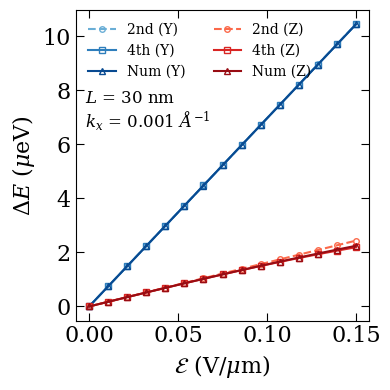

----------------------------------------
E (V/um)| gap (ueV)| alpha_p (meV nm^2/V)
----------------------------------------
0.011 0.747 6967.816
0.021 1.493 6967.748
0.032 2.24 6967.635
0.043 2.986 6967.477
0.054 3.732 6967.273
0.064 4.479 6967.025
0.075 5.225 6966.731
0.086 5.971 6966.392
0.096 6.717 6966.008
0.107 7.463 6965.58
0.118 8.209 6965.106
0.129 8.954 6964.588
0.139 9.7 6964.025
0.15 10.445 6963.417
----------------------------------------
E (V/um)| gap (ueV)| alpha_p (meV nm^2/V)
----------------------------------------
0.011 0.173 1618.681
0.021 0.346 1616.257
0.032 0.518 1612.269
0.043 0.689 1606.795
0.054 0.857 1599.933
0.064 1.023 1591.804
0.075 1.187 1582.541
0.086 1.348 1572.284
0.096 1.505 1561.175
0.107 1.66 1549.354
0.118 1.811 1536.956
0.129 1.96 1524.105
0.139 2.104 1510.915
0.15 2.246 1497.488


In [7]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================
#                      GLOBAL SETTINGS
# ==============================================================

plt.rcParams.update({
    "figure.figsize": [4, 4],
    "font.family": "Serif",
    "mathtext.fontset": "dejavuserif",
    "axes.linewidth": 0.8
})

# ==============================================================
#                      SPLITTING PLOT
# ==============================================================
N = 100
L = 300
kx = 0.001
emax = 0.15

datay_pb = np.loadtxt(f"Pymablock_Y_kx{kx}_emax_{emax:.2f}_N{N}_L{L}.dat", skiprows=1)
datay_num = np.loadtxt(f"numerical_splitting_N{N}_L{L}_emax{(emax):.2f}_y.dat", skiprows=1)

Efield = datay_pb[:, 0]
alpha_y = datay_pb[:, 1]
split_pb_2nd_y = datay_pb[:, 2]
split_pb_4th_y = datay_pb[:, 3]
split_num_y = datay_num[:, 3]



dataz_pb = np.loadtxt(f"Pymablock_Z_kx{kx}_emax_{emax:.2f}_N{N}_L{L}.dat", skiprows=1)
dataz_num = np.loadtxt(f"numerical_splitting_N{N}_L{L}_emax{(emax):.2f}_z.dat", skiprows=1)

Efield = dataz_pb[:, 0]
alpha_z = dataz_pb[:, 1]
split_pb_2nd_z = dataz_pb[:, 2]
split_pb_4th_z = dataz_pb[:, 3]
split_num_z = dataz_num[:, 3]

# Color maps
cmap_blue = plt.cm.Blues
cmap_red = plt.cm.Reds

# Pick 3 shades (light → dark)
blue_colors = cmap_blue([0.5, 0.7, 0.9])
red_colors  = cmap_red([0.5, 0.7, 0.9])

# ==============================================================
#                      PLOT
# ==============================================================

fig, ax = plt.subplots()

# Y = blue, Z = red

# Y direction (Blues)
ax.plot(Efield, split_pb_2nd_y, 'o--', color=blue_colors[0],
        label="2nd (Y)", markersize=4, markerfacecolor='None')

ax.plot(Efield, split_pb_4th_y, 's-', color=blue_colors[1],
        label="4th (Y)", markersize=4, markerfacecolor='None')

ax.plot(Efield, split_num_y, '^-', color=blue_colors[2],
        label="Num (Y)", markersize=4, markerfacecolor='None')


# Z direction (Reds)
ax.plot(Efield, split_pb_2nd_z, 'o--', color=red_colors[0],
        label="2nd (Z)", markersize=4, markerfacecolor='None')

ax.plot(Efield, split_pb_4th_z, 's-', color=red_colors[1],
        label="4th (Z)", markersize=4, markerfacecolor='None')

ax.plot(Efield, split_num_z, '^-', color=red_colors[2],
        label="Num (Z)", markersize=4, markerfacecolor='None')

ax.legend(frameon=False, ncol=2, fontsize = 10)
ax.text(0.03,0.62,f"$k_x$ = {kx}"r" $\AA^{-1}$", transform=ax.transAxes, fontsize = 12)
ax.text(0.03,0.7,f"$L$ = {int(L/10)} nm", transform=ax.transAxes,fontsize = 12)


# Labels
ax.set_xlabel(r"$\mathcal{E}$ (V/$\mu$m)", fontsize = 16)
ax.set_ylabel(r"$\Delta E$ ($\mu$eV)", fontsize = 16)
ax.tick_params(direction='in', length=6, width=0.8,
                   top=True, right=True, labelsize=16)

plt.tight_layout()
# plt.savefig(f"splitting_plot_N{N}_L{L}_kx{kx}.png",dpi=300)
plt.savefig(f"splitting_plot_N{N}_L{L}_kx{kx}.pdf",dpi=300)
plt.show()

print("-"*40)
print("E (V/um)| gap (ueV)| alpha_p (meV nm^2/V)")
print("-"*40)
for i in range(1,len(Efield)):
    print(Efield[i].round(3), split_num_y[i].round(3), (split_num_y[i]/(Efield[i]*kx*10)).round(3))

print("-"*40)
print("E (V/um)| gap (ueV)| alpha_p (meV nm^2/V)")
print("-"*40)
for i in range(1,len(Efield)):
    print(Efield[i].round(3), split_num_z[i].round(3), (split_num_z[i]/(Efield[i]*kx*10)).round(3))

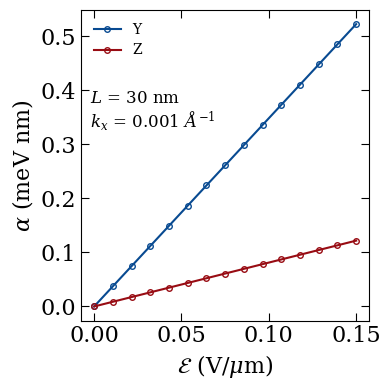

In [8]:

# ==============================================================
#                      RASHBA COEFFICIENT
# ==============================================================
N = 100
L = 300
kx = 0.001
emax = 0.15

datay_pb = np.loadtxt(f"Pymablock_Y_kx{kx}_emax_{emax:.2f}_N{N}_L{L}.dat", skiprows=1)
datay_num = np.loadtxt(f"numerical_splitting_N{N}_L{L}_emax{emax:.2f}_y.dat", skiprows=1)

Efield = datay_pb[:, 0]
alpha_y = datay_pb[:, 1]

dataz_pb = np.loadtxt(f"Pymablock_Z_kx{kx}_emax_{emax:.2f}_N{N}_L{L}.dat", skiprows=1)
dataz_num = np.loadtxt(f"numerical_splitting_N{N}_L{L}_emax{emax:.2f}_z.dat", skiprows=1)

Efield = dataz_pb[:, 0]
alpha_z = dataz_pb[:, 1]


fig, ax = plt.subplots()

# Y = blue, Z = red

# Y direction (Blues)
ax.plot(Efield, alpha_y*1e2, 'o-', color=blue_colors[2],
        label="Y", markersize=4, markerfacecolor='None')

# Z direction (Reds)
ax.plot(Efield, alpha_z*1e2, 'o-', color=red_colors[2],
        label="Z", markersize=4, markerfacecolor='None')

ax.legend(frameon=False, ncol=1, fontsize = 10)
ax.text(0.03,0.62,f"$k_x$ = {kx}"r" $\AA^{-1}$", transform=ax.transAxes, fontsize = 12)
ax.text(0.03,0.7,f"$L$ = {int(L/10)} nm", transform=ax.transAxes,fontsize = 12)
# ax.set_xlim(0,0.06)


# Labels
ax.set_ylabel(r"$\alpha$ (meV nm)", fontsize = 16)
ax.set_xlabel(r"$\mathcal{E}$ (V/$\mu$m)", fontsize = 16)
ax.tick_params(direction='in', length=6, width=0.8,
                   top=True, right=True, labelsize=16)

plt.tight_layout()
# plt.savefig(f"alpha_plot_N{N}_L{L}_kx{kx}.png",dpi=300)
plt.savefig(f"alpha_plot_N{N}_L{L}_kx{kx}.pdf",dpi=300)
plt.show()

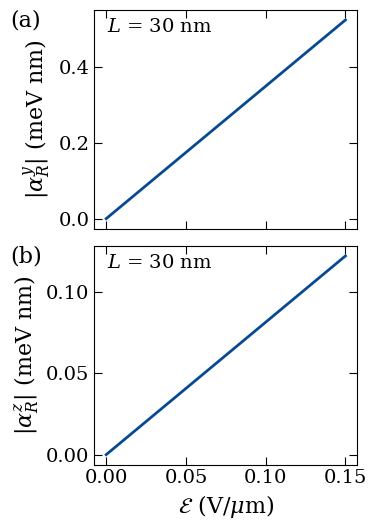

In [10]:
# ======= PLOT SETTINGS =======
plt.rcParams.update({
    "figure.figsize": [4, 5.4],
    "font.family": "Serif",
    "mathtext.fontset": "dejavuserif",
    "axes.linewidth": 0.8
})

cmap_blue = plt.cm.Blues
cmap_red = plt.cm.Reds
blue_colors = cmap_blue([0.5, 0.7, 0.9])
red_colors  = cmap_red([0.5, 0.7, 0.9])

# ======= CREATE 1x2 GRID =======
fig, (ax1, ax2) = plt.subplots(2, 1, sharex = True)

# --- Left Plot: Y Direction ---
ax1.plot(Efield, alpha_y * 1e2, 
         '-', 
         color=blue_colors[2],
         label=r"$\alpha_y$",
         linewidth=2, 
        #  markersize=5, 
        #  markerfacecolor='None'
         )
ax1.set_ylabel(r"$|\alpha_R^y|$ (meV nm)", fontsize=16)

# --- Right Plot: Z Direction ---
ax2.plot(Efield, alpha_z * 1e2, 
         '-', 
         color=blue_colors[2],
         label=r"$\alpha_z$",
         linewidth=2, 
        #  markersize=5, 
        #  markerfacecolor='None'
         )
ax2.set_ylabel(r"$|\alpha_R^z|$ (meV nm)", fontsize=16)

# --- Common Formatting ---
for ax in [ax1, ax2]:
    
    ax.tick_params(direction='in', length=6, width=0.8,
                   top=True, right=True, labelsize=14)
ax2.set_xlabel(r"$\mathcal{E}$ (V/$\mu$m)", fontsize=16)
# --- Text annotations ---
# ax1.text(0.05, 0.9, f"$k_x$ = {kx}"r" $\AA^{-1}$", transform=ax1.transAxes, fontsize=14)
ax1.text(0.05, 0.9, f"$L$ = {int(L/10)} nm", transform=ax1.transAxes, fontsize=14)
# ax1.text(0.05, 0.9, r"$\mathcal{E}$ || $y$", transform=ax1.transAxes, fontsize=14)

# ax2.text(0.05, 0.9, f"$k_x$ = {kx}"r" $\AA^{-1}$", transform=ax2.transAxes, fontsize=14)
ax2.text(0.05, 0.9, f"$L$ = {int(L/10)} nm", transform=ax2.transAxes, fontsize=14)
# ax2.text(0.05, 0.9, r"$\mathcal{E}$ || $z$", transform=ax2.transAxes, fontsize=14)

# --- Panel labels (a), (b) ---
ax1.text(-0.32, 1., "(a)", transform=ax1.transAxes,
         fontsize=16, va='top')

ax2.text(-0.32, 1., "(b)", transform=ax2.transAxes,
         fontsize=16, va='top')

# --- Layout ---
plt.tight_layout()
plt.subplots_adjust(wspace=0.35)  # <-- increase spacing here

# Save
plt.savefig(f"alpha_split_N{N}_L{L}_kx{kx}.png", dpi=300)
plt.savefig(f"alpha_split_N{N}_L{L}_kx{kx}.pdf", dpi=300)
plt.show()